# Задание 1.12

Матрица Адамара $H_n$: $H_n H_n^T = n I_n$, элементы $\pm 1$.

а) Выписать $H_1, H_2, H_4$.  
б) Показать $H_4 = H_2 \otimes H_2$.  
в) Показать $H_{2^k} = H_2 \otimes H_{2^{k-1}}$.  
г) Изобразить матрицу Адамара для $n=2^6$.


## Теория

Конструкция Сильвестра:
$$H_1 = (1),\quad H_{2^k} = \begin{pmatrix} H_{2^{k-1}} & H_{2^{k-1}}\\ H_{2^{k-1}} & -H_{2^{k-1}}\end{pmatrix} = H_2 \otimes H_{2^{k-1}}.$$


H1 =
 [[1]]
H2 =
 [[ 1  1]
 [ 1 -1]]
H4 =
 [[ 1  1  1  1]
 [ 1 -1  1 -1]
 [ 1  1 -1 -1]
 [ 1 -1 -1  1]]
H4 == H2⊗H2: True
Свойство Hn Hn^T = nI проверено для n=2..64


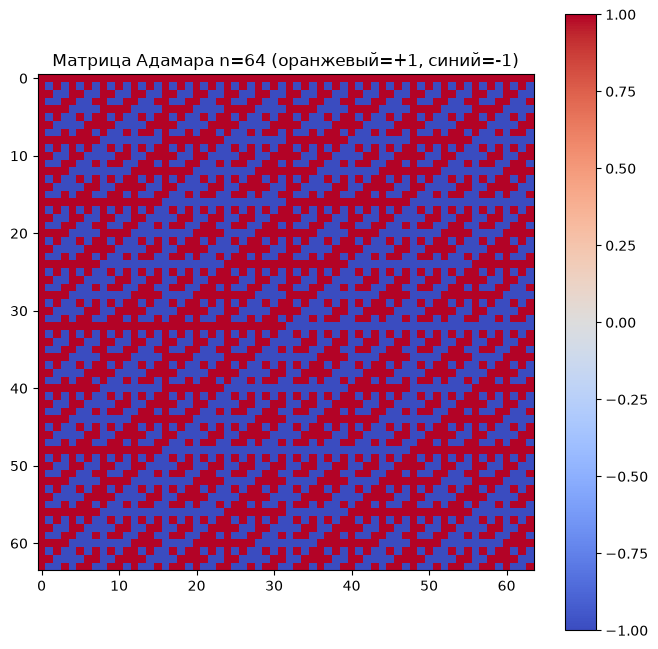

In [2]:
import numpy as np
import matplotlib.pyplot as plt

H1 = np.array([[1]])
H2 = np.array([[1, 1],[1,-1]])
H4 = np.kron(H2, H2)
print("H1 =\n", H1)
print("H2 =\n", H2)
print("H4 =\n", H4)

# Проверка H4 = H2 ⊗ H2
print("H4 == H2⊗H2:", np.array_equal(H4, np.kron(H2, H2)))

# Проверка Hn Hn^T = n I
for k in range(1, 7):
    H = H1
    for _ in range(k):
        H = np.kron(H2, H) if H.shape[0] > 1 else H2
    n = H.shape[0]
    assert np.array_equal(H @ H.T, n*np.eye(n)), "Ошибка!"
print("Свойство Hn Hn^T = nI проверено для n=2..64")

# Визуализация для n = 2^6 = 64
n = 64
H = H2.copy()
while H.shape[0] < n:
    H = np.kron(H2, H)

plt.figure(figsize=(8, 8))
plt.imshow(H, cmap='coolwarm', interpolation='nearest')
plt.title(f"Матрица Адамара n={n} (оранжевый=+1, синий=-1)")
plt.colorbar()
plt.show()
